In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
os.environ['KERAS_BACKEND'] = 'jax'
os.environ["JAX_PLATFORMS"] = "cpu"
import keras

import joblib
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import spearmanr, pearsonr, norm, kstest, cramervonmises
from sklearn.metrics import r2_score
from scipy.special import erf

In [ ]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams['font.size'] = 12

ibm_cmap = LinearSegmentedColormap.from_list("ibm", ['#648eff', '#785eef', '#db267e', '#fd6000', '#ffaf00'], N=256)

# Load data

In [3]:
def transform(x):
    return np.log10(x + 1)

def inv_transform(y):
    return 10**y - 1

In [ ]:
x_test = pd.read_hdf('Data/PEACE_AND_RAPID/Eclipse 3D/GENET 0.1.1/x_test_scaled.h5')
y_test = pd.read_hdf('Data/PEACE_AND_RAPID/Eclipse 3D/GENET 0.1.1/y_test.h5')

In [ ]:
ce = pd.read_hdf('Data/PEACE_AND_RAPID/Eclipse 3D/GENET 0.1.1/ce_test.h5')

# Load model

In [ ]:
scaler = joblib.load('Models/genet-0.1.1.scaler.save')

def add_stopgrad_base(inputs):
    base, dist = inputs
    return keras.ops.stop_gradient(base) + dist

model = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p50.keras', custom_objects={
    'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base
})

In [9]:
base_features = [1, 2, 3, 4, 0, 5]

# Calculate performance metrics

In [ ]:
pred_base, pred_full = model.predict([x_test.iloc[:, base_features], x_test], batch_size=2**17)

In [12]:
def relu(x):
    return np.maximum(x, 0)

pred_base_flux = relu(pred_base)
pred_full_flux = relu(pred_full)

In [13]:
o = y_test.to_numpy().ravel()
m = pred_full_flux.ravel()
m_baseline = pred_base_flux.ravel()

filter_positive = (o > 0) & (m > 0)
o_pos = o[filter_positive]
m_pos = m[filter_positive]
m_baseline_pos = m_baseline[filter_positive]

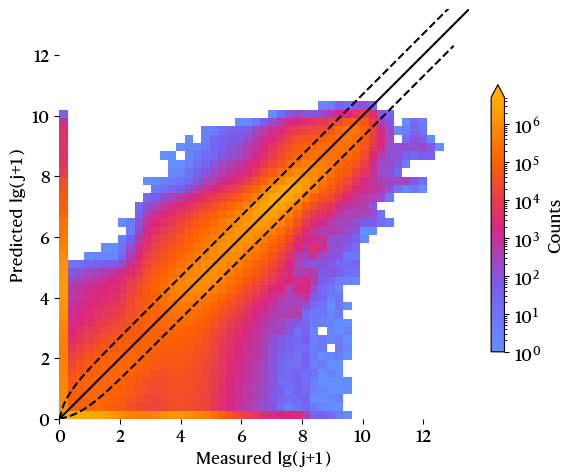

In [46]:
scale = 294.8562 / 308.016
fig, ax = plt.subplots(figsize=(6*scale, 6*scale))
ax.set_aspect(1)

# hst = ax.hist2d(o, m, bins=[np.linspace(0, 13.5, 50)]*2, norm='log', cmap=ibm_cmap, vmin=10**0, vmax=10**7.65)
hst = ax.hist2d(o, m, bins=[np.linspace(0, 13.5, 50)]*2, norm='log', cmap=ibm_cmap, vmin=10**0, vmax=10**6.7)
fig.colorbar(hst[3], ax=ax, label='Counts', fraction=0.03, extend="max")
ax.axline((0, 0), (1, 1), c='k')

xs = np.linspace(0, 13, 100)
ax.plot(xs, transform(inv_transform(xs)*5), c='k', linestyle='--')
ax.plot(xs, transform(inv_transform(xs)/5), c='k', linestyle='--')

ax.set_xticks(np.arange(0, 13, 2))
ax.set_yticks(np.arange(0, 13, 2))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('Measured  lg( j+1 )')
ax.set_ylabel('Predicted  lg( j+1 )')

plt.show()

fig.savefig('Plots/performance_hist.pdf', bbox_inches='tight')

## Accuracy

In [18]:
# RMSE
def rmse(o, m):
    return np.sqrt(np.nanmean((o - m)**2))

rmse(o, m), rmse(o_pos, m_pos)

(np.float64(1.4659631795785686), np.float64(0.6983155026549259))

In [14]:
# MSE
def mse(o, m):
    return np.nanmean((o - m)**2)

mse(o, m), mse(o_pos, m_pos)

(np.float64(2.1298080075161163), np.float64(0.5144738518809618))

In [39]:
# MAE
def mae(o, m):
    return np.nanmean(np.abs(o - m))

mae(o, m), mae(o_pos, m_pos)

(np.float64(0.7673342903912115), np.float64(0.4686733965882515))

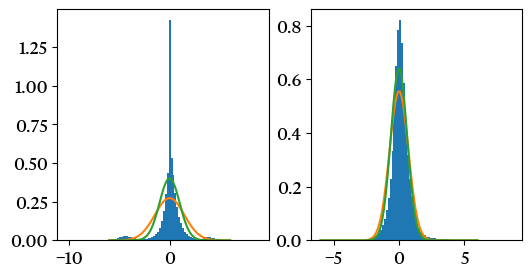

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].hist(o - m, bins=100, density=True)
sigma = rmse(o, m)
ax[0].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))
sigma = mae(o, m) * np.sqrt(np.pi / 2)
ax[0].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))

ax[1].hist(o_pos - m_pos, bins=100, density=True)
sigma = rmse(o_pos, m_pos)
ax[1].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))
sigma = mae(o_pos, m_pos) * np.sqrt(np.pi / 2)
ax[1].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))

plt.show()

In [16]:
# SMAPE
def smape(o, m):
    return 100 * np.nanmean(np.abs((o - m) / (0.5 * (o + m))))

smape(o, m), smape(o_pos, m_pos), smape(10**o, 10**m), smape(10**o_pos, 10**m_pos)

/tmp/ipykernel_1543789/3626746634.py:3: RuntimeWarning: invalid value encountered in divide
  return 100 * np.nanmean(np.abs((o - m) / (0.5 * (o + m))))


(np.float64(56.090051316375835),
 np.float64(12.288517151822147),
 np.float64(85.7779246482174),
 np.float64(84.31054928845923))

In [17]:
# MSA
def msa(o, m):
    return 100 * (np.exp(np.nanmedian(np.abs(np.log(m / o)))) - 1)

msa(o, m), msa(o_pos, m_pos), msa(10**o, 10**m), msa(10**o_pos, 10**m_pos)

/tmp/ipykernel_1543789/4162992145.py:3: RuntimeWarning: divide by zero encountered in divide
  return 100 * (np.exp(np.nanmedian(np.abs(np.log(m / o)))) - 1)
/tmp/ipykernel_1543789/4162992145.py:3: RuntimeWarning: invalid value encountered in divide
  return 100 * (np.exp(np.nanmedian(np.abs(np.log(m / o)))) - 1)
/tmp/ipykernel_1543789/4162992145.py:3: RuntimeWarning: divide by zero encountered in log
  return 100 * (np.exp(np.nanmedian(np.abs(np.log(m / o)))) - 1)


(np.float64(9.13721208739684),
 np.float64(5.812613000283262),
 np.float64(118.4136639369589),
 np.float64(122.88166276160682))

In [20]:
def ecdf(o, m, times):
    o_inv = 10**o - 1
    m_inv = 10**m - 1
    return ((m_inv <= o_inv * times) & (m_inv >= o_inv / times)).sum() / len(o)

# ecdf(o, m, 5), ecdf(o_pos, m_pos, 5), ecdf(o_pos, m_baseline_pos, 5)
ecdf(o_pos, m_pos, 5)

np.float64(0.7770540771931379)

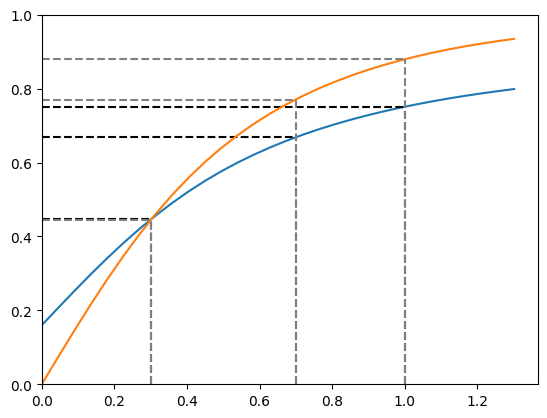

In [ ]:
def fac(o, m, threshold):
    return np.nansum(np.abs(o - m) <= threshold) / len(o)

thresholds = np.linspace(0, np.log10(20), 30)
facs = [fac(o, m, thresholds[i]) for i in range(len(thresholds))]
plt.plot(thresholds, facs)

for ratio in [2, 5, 10]:
    plt.vlines(np.log10(ratio), ymin=0, ymax=fac(o, m, np.log10(ratio)), color='k', linestyle='--')
    plt.hlines(fac(o, m, np.log10(ratio)), xmin=0, xmax=np.log10(ratio), color='k', linestyle='--')

facs = [fac(o_pos, m_pos, thresholds[i]) for i in range(len(thresholds))]
plt.plot(thresholds, facs)
for ratio in [2, 5, 10]:
    plt.vlines(np.log10(ratio), ymin=0, ymax=fac(o_pos, m_pos, np.log10(ratio)), color='grey', linestyle='--')
    plt.hlines(fac(o_pos, m_pos, np.log10(ratio)), xmin=0, xmax=np.log10(ratio), color='grey', linestyle='--')
    
plt.xlim(0)
plt.ylim([0, 1])
plt.show()

In [40]:
# Robust rmse?
def smad(o, m):
    return np.nanmedian(np.abs(o - m)) / 0.67449

smad(o, m), smad(o_pos, m_pos)

(np.float64(0.46589370578447564), np.float64(0.4847372485515013))

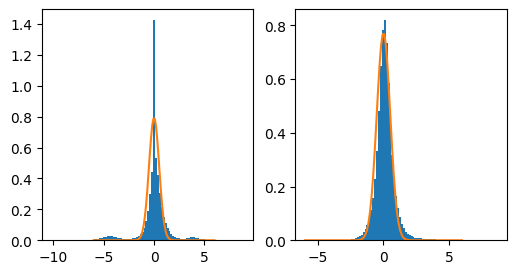

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].hist(o - m, bins=100, density=True)
sigma = smad(o, m)
ax[0].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))

ax[1].hist(o_pos - m_pos, bins=100, density=True)
sigma = smad(o_pos, m_pos)
ax[1].plot(np.linspace(-6, 6, 100), np.sqrt(1 / (2 * np.pi * sigma**2)) * np.exp(-np.linspace(-6, 6, 100)**2 / (2 * sigma**2)))

plt.show()

## Bias

In [39]:
# ME
def me(o, m):
    return np.nanmean(m) - np.nanmean(o)

me(o, m), me(o_pos, m_pos)

(np.float64(0.07520948904656688), np.float64(-0.09344857000334716))

In [183]:
# MPE
def mpe(o, m):
    return 100 * np.nanmedian((m - o) / o)

mpe(o, m), mpe(o_pos, m_pos)

/tmp/ipykernel_290621/2998120220.py:3: RuntimeWarning: divide by zero encountered in divide
  return 100 * np.nanmedian((m - o) / o)
/tmp/ipykernel_290621/2998120220.py:3: RuntimeWarning: invalid value encountered in divide
  return 100 * np.nanmedian((m - o) / o)


(np.float64(-0.4744181302551411), np.float64(-0.311872791024418))

In [184]:
# SSPB
def sspb(o, m):
    med_log = np.nanmedian(np.log(m / o))
    return 100 * np.sign(med_log) * (np.exp(np.abs(med_log)) - 1)

sspb(o, m), sspb(o_pos, m_pos)

/tmp/ipykernel_290621/3855673088.py:3: RuntimeWarning: divide by zero encountered in divide
  med_log = np.nanmedian(np.log(m / o))
/tmp/ipykernel_290621/3855673088.py:3: RuntimeWarning: invalid value encountered in divide
  med_log = np.nanmedian(np.log(m / o))
/tmp/ipykernel_290621/3855673088.py:3: RuntimeWarning: divide by zero encountered in log
  med_log = np.nanmedian(np.log(m / o))


(np.float64(-0.4766795846278482), np.float64(-0.3128484803116338))

## Precision

In [81]:
# YI
def yi(o, m):
    return (np.nanmax(m) - np.nanmin(m)) / (np.nanmax(o) - np.nanmin(o))

yi(o, m), yi(o_pos, m_pos)

(np.float64(0.8256326778066706), np.float64(0.8256326835089155))

In [20]:
# P std, ratio
def p_std_ratio(o, m):
    return np.nanstd(m) / np.nanstd(o) 

p_std_ratio(o, m), p_std_ratio(o_pos, m_pos)

(np.float64(0.9821703711477002), np.float64(1.0305554360922433))

In [83]:
# P std, diff
def p_std_diff(o, m):
    return np.nanstd(m) - np.nanstd(o) 

p_std_diff(o, m), p_std_diff(o_pos, m_pos)

(np.float64(-0.050707666654831396), np.float64(0.39557700959994424))

## Association

In [19]:
# R2
def r2(o, m):
    filter_nan = ~np.isnan(o) & ~np.isnan(m)
    return r2_score(o[filter_nan], m[filter_nan])

r2(o, m), r2(o_pos, m_pos)

(0.7802495111831292, 0.8506453718974663)

In [25]:
# r
def r(o, m):
    filter_nan = ~np.isnan(o) & ~np.isnan(m)
    return pearsonr(o[filter_nan], m[filter_nan]).correlation

r(o, m), r(o_pos, m_pos)

(np.float64(0.8894634015845034), np.float64(0.9293169572980383))

In [29]:
# rs
def rs(o, m):
    filter_nan = ~np.isnan(o) & ~np.isnan(m)
    return spearmanr(o[filter_nan], m[filter_nan]).correlation

rs(o, m), rs(o_pos, m_pos)

(np.float64(0.9004916961169156), np.float64(0.9348695453246438))

## Skill

In [187]:
# PE
def pe(o, m):
    return 1 - np.nansum((m - o)**2) / np.nansum((o - np.nanmean(o))**2)

pe(o, m), pe(o_pos, m_pos)

(np.float64(0.7560756047096588), np.float64(0.9111265816671252))

In [41]:
# Skill score
def skill(o, m_old, m_new, metric):
    metric_new = metric(o, m_new)
    metric_old = metric(o, m_old)
    print(metric_old, metric_new)
    return (metric_new - metric_old) / (metric(o, o) - metric_old)

skill(o, m_baseline, m, metric=mse), skill(o_pos, m_baseline_pos, m_pos, metric=mse)

2.245381075768751 2.0891281144365568
1.2157801603564264 1.1498731923298244


(np.float64(0.06958861594515658), np.float64(0.0542096097433275))

# Classification metrics

In [21]:
o_zero = y_test.to_numpy().ravel() == 0
m_zero = pred_full_flux.ravel() == 0
m_baseline_zero = pred_base_flux.ravel() == 0

In [22]:
# Accuracy
def accuracy(o, m):
    o = np.asarray(o)
    m = np.asarray(m)
    mask = np.isfinite(o) & np.isfinite(m)
    if not np.any(mask):
        return np.nan
    return np.mean(o[mask] == m[mask])

accuracy(o_zero, m_zero)

np.float64(0.8053202321606776)

In [23]:
# Precision
def precision(o, m):
    o = np.asarray(o)
    m = np.asarray(m)
    mask = np.isfinite(o) & np.isfinite(m)
    if not np.any(mask):
        return np.nan
    tp = np.sum((o[mask] == 1) & (m[mask] == 1))
    fp = np.sum((o[mask] == 0) & (m[mask] == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

precision(o_zero, m_zero)

np.float64(0.5863224013928298)

In [24]:
# Recall
def recall(o, m):
    o = np.asarray(o)
    m = np.asarray(m)
    mask = np.isfinite(o) & np.isfinite(m)
    if not np.any(mask):
        return np.nan
    tp = np.sum((o[mask] == 1) & (m[mask] == 1))
    fn = np.sum((o[mask] == 1) & (m[mask] == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

recall(o_zero, m_zero)

np.float64(0.6694618640499965)

In [25]:
# F1 score
def f1(o, m):
    p = precision(o, m)
    r = recall(o, m)
    return 2 * p * r / (p + r)

f1(o_zero, m_zero)

np.float64(0.6251399998745802)

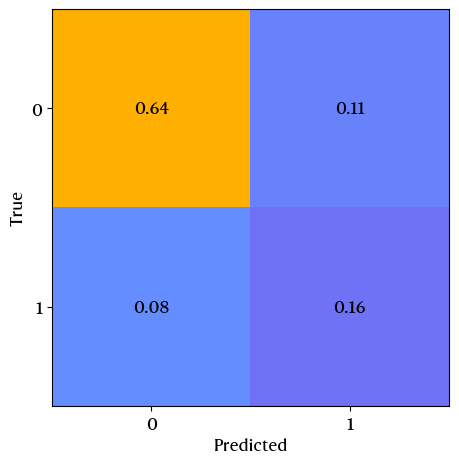

In [25]:
def plot_confusion(o, m):
    o = np.asarray(o).astype(int)
    m = np.asarray(m).astype(int)

    mask = np.isfinite(o) & np.isfinite(m)
    o = o[mask]
    m = m[mask]

    n = len(o)
    tp = np.sum((o == 1) & (m == 1))
    tn = np.sum((o == 0) & (m == 0))
    fp = np.sum((o == 0) & (m == 1))
    fn = np.sum((o == 1) & (m == 0))

    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.imshow(cm, cmap=ibm_cmap)
    plt.xticks([0, 1], ['0', '1'])
    plt.yticks([0, 1], ['0', '1'])
    plt.xlabel('Predicted')
    plt.ylabel('True')

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f'{cm[i, j]/n:.2f}', ha='center', va='center')

    plt.tight_layout()
    plt.show()

plot_confusion(o_zero, m_zero)

# Three Q

In [ ]:
model_q05 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p5.keras', custom_objects={'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base})
model_q25 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p25.keras', custom_objects={'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base})
model_q75 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p75.keras', custom_objects={'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base})
model_q95 = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p95.keras', custom_objects={'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base})

In [16]:
pred_base_q05, pred_full_q05 = model_q05.predict([x_test.iloc[:, base_features], x_test], batch_size=2**17)
pred_base_q25, pred_full_q25 = model_q25.predict([x_test.iloc[:, base_features], x_test], batch_size=2**17)
pred_base_q75, pred_full_q75 = model_q75.predict([x_test.iloc[:, base_features], x_test], batch_size=2**17)
pred_base_q95, pred_full_q95 = model_q95.predict([x_test.iloc[:, base_features], x_test], batch_size=2**17)

pred_base_q05 = relu(pred_base_q05)
pred_full_q05 = relu(pred_full_q05)
pred_base_q25 = relu(pred_base_q25)
pred_full_q25 = relu(pred_full_q25)
pred_base_q75 = relu(pred_base_q75)
pred_full_q75 = relu(pred_full_q75)
pred_base_q95 = relu(pred_base_q95)
pred_full_q95 = relu(pred_full_q95)

219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step   
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step   
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step   
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step   


In [17]:
m_q05 = pred_full_q05.ravel()
m_q25 = pred_full_q25.ravel()
m_q75 = pred_full_q75.ravel()
m_q95 = pred_full_q95.ravel()

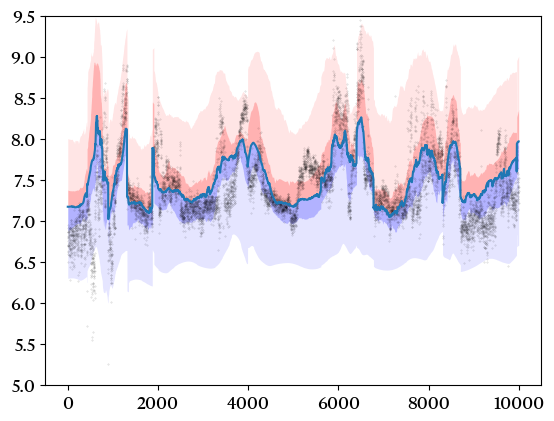

In [ ]:
filter_e = np.repeat(ce['Energy channel'] == 1, 9)
filter_c = np.repeat(ce['C'] == 2, 9)
f = filter_e & filter_c

i_pa = 4
start = 460_000
stop = 470_000
s = slice(start * 9 + i_pa, stop * 9, 9)

inds = range(len(m[f][s]))

plt.plot(inds, m[f][s])

plt.fill_between(inds, m_q05[f][s], m_q25[f][s], alpha=0.1, linewidth=0, color='b')
plt.fill_between(inds, m_q25[f][s], m[f][s], alpha=0.3, linewidth=0, color='b')
plt.fill_between(inds, m[f][s], m_q75[f][s], alpha=0.3, linewidth=0, color='r')
plt.fill_between(inds, m_q75[f][s], m_q95[f][s], alpha=0.1, linewidth=0, color='r')

plt.scatter(inds, o[f][s], s=0.1, alpha=0.2, c='k')

plt.ylim(5, 9.5)

plt.show()

In [19]:
below_05 = (o <= m_q05).sum() / len(o)
below_25 = (o <= m_q25).sum() / len(o)
below_50 = (o <= m).sum() / len(o)
below_75 = (o <= m_q75).sum() / len(o)
below_95 = (o <= m_q95).sum() / len(o)
below_05, below_25, below_50, below_75, below_95

(np.float64(0.25108645855697015),
 np.float64(0.34481215850037433),
 np.float64(0.5247156270374478),
 np.float64(0.7593893338614274),
 np.float64(0.9316109555186346))

In [22]:
p_0 = (o == 0).sum() / len(o)
p_0

np.float64(0.24247846210629775)

In [23]:
def perfect_curve(x, p_0):
    x = np.asarray(x)
    return np.where(x <= p_0, p_0, x)

def miscalibration_area(x_model, y_model, p_0):
    x_all = np.unique(np.concatenate([x_model, [p_0]]))
    y_model_interp = np.interp(x_all, x_model, y_model)
    y_perfect = perfect_curve(x_all, p_0)
    area = np.trapezoid(np.abs(y_model_interp - y_perfect), x_all)
    return area

area = miscalibration_area([0.05, 0.25, 0.50, 0.75, 0.95],
                           np.array([below_05, below_25, below_50, below_75, below_95]),
                        #    np.array([p_0, 0.25, 0.5, 0.75, 0.95]),
                           p_0)
print(area)

0.033047813657198125


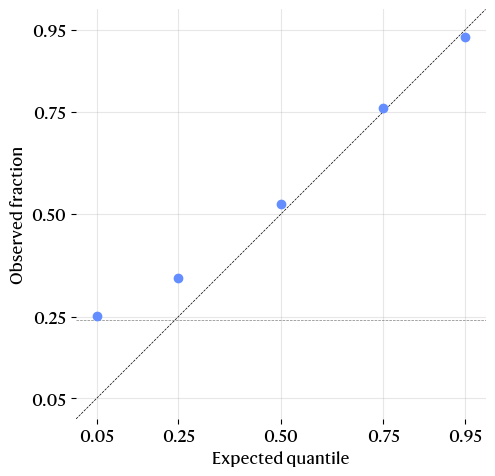

In [ ]:
scale = (294.8562 / 308.016) * (294.8562 / 318.42)
fig, ax = plt.subplots(figsize=(6*scale, 6*scale))
ax.set_aspect(1)

q_levels = [0.05, 0.25, 0.50, 0.75, 0.95]
obs_levels = [below_05, below_25, below_50, below_75, below_95]
# obs_levels_pos = [below_05_pos, below_25_pos, below_50_pos, below_75_pos, below_95_pos]

ax.axline((0, 0), (1, 1), linestyle='--', c='k', linewidth=0.5)
ax.axhline(p_0, linestyle='--', c='gray', linewidth=0.5)
# plt.fill_between([0, 1], p_0, color=ibm_cmap(0), alpha=0.2, linewidth=0)

plt.plot(q_levels, obs_levels, 'o', linewidth=1.5, c=ibm_cmap(0), label='With zeros')
# plt.plot(q_levels, obs_levels_pos, 'o', linewidth=1.5, c=ibm_cmap(255), label='Without zeros')

plt.xlabel('Expected quantile')
plt.ylabel('Observed fraction')
plt.xlim(0, 1)
plt.ylim(0, 1)

ax.set_xticks(q_levels)
ax.set_yticks(q_levels)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(alpha=0.3)


fig.savefig('Plots/calibration_plot.pdf', bbox_inches='tight')